In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [5]:
class ChainState(TypedDict):
    topic: str
    ans: str

In [7]:
def gen_outline(state: ChainState) -> ChainState:
    topic = state['topic']
    prompt = f'Create an outline for the topic {topic}'
    
    response = model.invoke(prompt)
    state['ans'] = response.content
    return state

In [8]:
def gen_blog(state: ChainState) -> ChainState:
    outline = state['ans']
    prompt = f'Create a blog from the given outline {outline}'
    
    response = model.invoke(prompt)
    state['ans'] = response.content
    return state

In [10]:
graph = StateGraph(ChainState)

graph.add_node('gen_outline', gen_outline)
graph.add_node('gen_blog', gen_blog)

graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', END)

workflow = graph.compile()

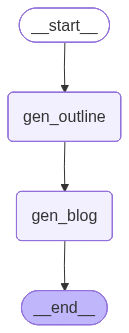

In [11]:
workflow

In [12]:
initial_state = {'topic': 'System'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'System', 'ans': '## Beyond the Parts: Unpacking the Concept of "System" and Why It Matters\n\nLook around you. Really look. From the device you\'re reading this on to the air you breathe, the traffic flowing outside, and even your own body – everything is interconnected, working in concert. This intricate web of relationships is governed by one fundamental concept: the **system**.\n\nFar from being a dry academic term, understanding systems is key to unlocking complexity, solving problems, and designing a better future. Let\'s dive deep into what a system truly is.\n\n---\n\n### I. Introduction to Systems: The World in Interconnected Pieces\n\nAt its core, a **system** is a set of interacting or interdependent components that form an integrated whole, working together towards a common objective or purpose. The magic happens because a system is always **more than the sum of its parts** – it possesses "emergent properties" that individual components don\'t have.\n\nSystems are